# Are there economic regions in the Czech Republic that affect the accessibility of hospitals?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import statsmodels.api as sm
import plotly.graph_objects as go

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import plotly.graph_objects as go

Load data

We already know that economic factors are strongly correlated (see income_capacity.ipynb), so we will use only DPFO.

In [3]:
# Load data
cities_df = pd.read_csv('../data/cities_with_all_data.csv')
cols = ['Nazev_obce_prijmy', 'Nejblizsi_nemocnice', 'Vzdalenost_km', 'Lat_x', 'Lon_x', 'DPFO', 'Total', 'Cislo_obce', 'Index_stari']
cities_df = cities_df[cols].dropna()

print("Praha: ", cities_df[cities_df["Cislo_obce"]==554782])

# drop cities with extreme DPFO values
cities_df['DPFO_per_capita'] = cities_df['DPFO'].copy()
cities_df['DPFO_per_capita'] = cities_df['DPFO'] / cities_df['Total']
cities_df = cities_df[(cities_df['DPFO_per_capita'] > cities_df['DPFO_per_capita'].quantile(0.01)) & (cities_df['DPFO_per_capita'] < cities_df['DPFO_per_capita'].quantile(0.99))]

Praha:  Empty DataFrame
Columns: [Nazev_obce_prijmy, Nejblizsi_nemocnice, Vzdalenost_km, Lat_x, Lon_x, DPFO, Total, Cislo_obce, Index_stari]
Index: []


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

def compute_W_for_ks(X, ks, random_state=42, n_init="auto"):
    W = []
    for k in ks:
        km = KMeans(n_clusters=k, random_state=random_state, n_init=n_init)
        km.fit(X)
        W.append(km.inertia_)  # W(k) = inertia
    return np.array(W, dtype=float)

def elbow_choose_k(ks, W):
    """
    Automatic elbow: choose k with maximum distance from the line
    connecting (k_min, W_min) to (k_max, W_max).
    Works best when ks are increasing.
    """
    ks = np.asarray(ks, dtype=float)
    W = np.asarray(W, dtype=float)

    # Points
    x1, y1 = ks[0], W[0]
    x2, y2 = ks[-1], W[-1]

    # Distance of each point to the line (x1,y1)-(x2,y2)
    # Using cross product magnitude / line length
    line_len = np.hypot(x2 - x1, y2 - y1) + 1e-12
    dist = np.abs((y2 - y1) * ks - (x2 - x1) * W + x2 * y1 - y2 * x1) / line_len

    idx = int(np.argmax(dist))
    return int(ks[idx])


def plot_elbow_with_distances(ks, W, k_star=None):
    ks = np.asarray(ks, dtype=float)
    W = np.asarray(W, dtype=float)

    # Line endpoints
    x1, y1 = ks[0], W[0]
    x2, y2 = ks[-1], W[-1]

    # Line length
    line_len = np.hypot(x2 - x1, y2 - y1) + 1e-12

    # Distances to line
    distances = np.abs(
        (y2 - y1) * ks - (x2 - x1) * W + x2 * y1 - y2 * x1
    ) / line_len

    plt.figure(figsize=(9, 5))

    # Inertia curve
    plt.plot(ks, W, marker='o', label="W(k)")

    # Reference line
    plt.plot([x1, x2], [y1, y2], linestyle='--', color='gray',
             label="Reference line")


    # Highlight elbow
    if k_star is not None:
        plt.axvline(k_star, linestyle='--', color='black',
                    label=f"Selected k = {k_star}")

    plt.xlabel("k")
    plt.ylabel("Inertia W(k)")
    plt.title("Elbow method with perpendicular distances")
    plt.legend()
    plt.tight_layout()
    plt.show()

Lets start by ploting DPFO_per_capita in 3D space (longitude, latitude, DPFO_per_capita).

In [5]:
# Plot DPFO of cities in a 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=cities_df['Lon_x'],
    y=cities_df['Lat_x'],
    z=cities_df['DPFO_per_capita'],
    mode='markers',
    marker=dict(
        size=5,
        color=cities_df['DPFO_per_capita'],  # set color to DPFO
        colorscale='Rainbow',  # choose a colorscale
        opacity=0.8
    ),
    hovertext=cities_df['Nazev_obce_prijmy']
)])
fig.update_layout(
    scene=dict(
        xaxis_title='Longitude',
        yaxis_title='Latitude',
        zaxis_title='DPFO_per_capita',
        xaxis=dict(autorange='reversed'),
        yaxis=dict(autorange='reversed')
    ),
    title='3D Scatter Plot of Cities by DPFO'
)
fig.show()

We see that accros Czechia tthere is wide range of DPFO_per_capita but it doesnt seem to depend on geographical location.

Lets now perform clustering based on DPFO_per_capita.

Optimal number of clusters (k*): 4


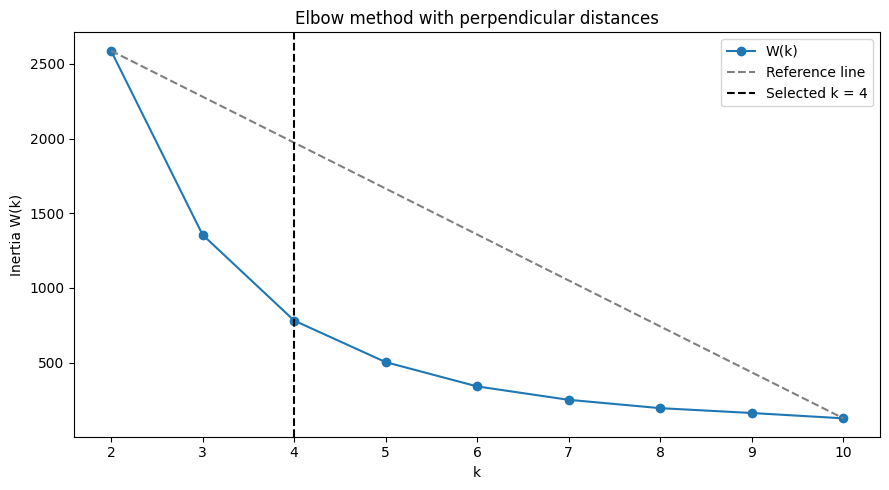

In [6]:
# perform clustering based on DPFO_per_capita
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cities_df[['DPFO_per_capita']])
number_of_clusters = 4
kmeans = KMeans(n_clusters=number_of_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

# Sort clusters by their center values (lowest to highest)
cluster_centers = kmeans.cluster_centers_.flatten()
cluster_order = np.argsort(cluster_centers)
cluster_mapping = {old_label: new_label for new_label, old_label in enumerate(cluster_order)}
cities_df['cluster'] = np.array([cluster_mapping[label] for label in cluster_labels])
# Plot clusters in 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=cities_df['Lon_x'],
    y=cities_df['Lat_x'],
    z=cities_df['DPFO_per_capita'],
    mode='markers',
    marker=dict(
        size=2,
        color=cities_df['cluster'],  # set color to cluster
        colorscale='Jet',  # choose a colorscale
        opacity=0.8
    ),
    hovertext=cities_df['Nazev_obce_prijmy']
)])
fig.update_layout(
    scene = dict(
        xaxis_title='Longitude',
        yaxis_title='Latitude',
        zaxis_title='DPFO_per_capita',
        xaxis=dict(autorange='reversed'),
        yaxis=dict(autorange='reversed'),
        camera=dict(eye=dict(x=1.5, y=1.5, z=0.1))
    ),
    title='3D Scatter Plot of Cities by DPFO Clusters'
)
fig.show()

# Determine optimal number of clusters using Gap Statistic
K_VALUES = [2, 3, 4, 5, 6, 7, 8, 9, 10]

W = compute_W_for_ks(X_scaled, ks=K_VALUES)
k_star = elbow_choose_k(ks=K_VALUES, W=W)
print(f"Optimal number of clusters (k*): {k_star}")
plot_elbow_with_distances(ks=sorted(K_VALUES), W=W, k_star=k_star)

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import numpy as np

# -----------------------------
# Params (same as before)
# -----------------------------
K_VALUES = [2, 3, 4, 5, 6, 7]
ROWS, COLS = 2, 3

HSPACE = 0.06
VSPACE = 0.10

EXPORT_W = 2000
EXPORT_H = 1200
EXPORT_SCALE = 3

# -----------------------------
# Scale DPFO_per_capita
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cities_df[['DPFO_per_capita']])

# -----------------------------
# Create subplot grid: 2 rows x 3 cols
# -----------------------------
fig = make_subplots(
    rows=ROWS,
    cols=COLS,
    specs=[[{'type': 'scene'}] * COLS for _ in range(ROWS)],
    subplot_titles=[f'k = {k}' for k in K_VALUES],
    horizontal_spacing=HSPACE,
    vertical_spacing=VSPACE
)

# -----------------------------
# Add traces (k = 2..7)
# -----------------------------
for idx, k in enumerate(K_VALUES):
    row = idx // COLS + 1
    col = idx % COLS + 1

    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    # Order clusters by DPFO center (low -> high)
    centers = kmeans.cluster_centers_.flatten()
    order = np.argsort(centers)
    mapping = {old: new for new, old in enumerate(order)}
    ordered_labels = np.array([mapping[l] for l in labels])

    fig.add_trace(
        go.Scatter3d(
            x=cities_df['Lon_x'],
            y=cities_df['Lat_x'],
            z=cities_df['DPFO_per_capita'],
            mode='markers',
            marker=dict(
                size=2,
                color=ordered_labels,
                colorscale='Jet',
                opacity=0.8
            ),
            hovertext=cities_df['Nazev_obce_prijmy'],
            showlegend=False
        ),
        row=row,
        col=col
    )

    fig.update_scenes(
        dict(
            xaxis_title='Lon.',
            yaxis_title='Lat.',
            zaxis_title='DPFO per capita',
            xaxis=dict(autorange='reversed'),
            yaxis=dict(autorange='reversed'),
            camera=dict(eye=dict(x=1.5, y=1.5, z=0.1))
        ),
        row=row,
        col=col
    )

# Subplot titles font
fig.update_annotations(font=dict(size=26))

# -----------------------------
# Layout + save
# -----------------------------
fig.update_layout(
    height=EXPORT_H,
    width=EXPORT_W,
    title=dict(
        text='Clustering by DPFO per Capita (k = 2–7)',
        font=dict(size=32),
        x=0.5,
        xanchor='center'
    ),
    margin=dict(l=10, r=10, b=10, t=60)
)

fig.show()

fig.write_image(
    "../results/3d_scatter_dpfo_clusters_k2_3_4_5_6_7.pdf",
    width=EXPORT_W,
    height=EXPORT_H,
    scale=EXPORT_SCALE
)

# Optional: often looks better than PDF for 3D
fig.write_image(
    "../results/3d_scatter_dpfo_clusters_k2_3_4_5_6_7.png",
    width=EXPORT_W,
    height=EXPORT_H,
    scale=EXPORT_SCALE
)

Now perform clustering based on the distance to nearest hospital

Optimal number of clusters (k*): 4


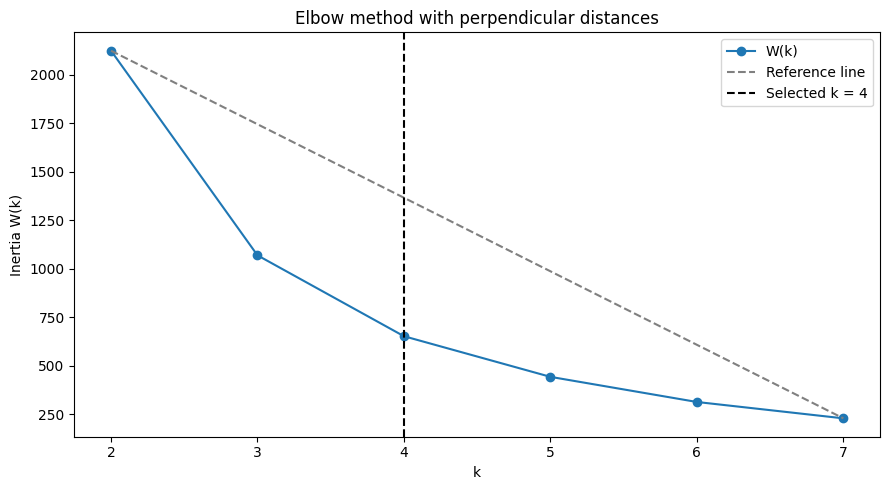

In [8]:
# perform clustering based on Vzdalenost_km
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cities_df[['Vzdalenost_km']])
number_of_clusters = 4
kmeans = KMeans(n_clusters=number_of_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

# Sort clusters by their center values (lowest to highest distance)
cluster_centers = kmeans.cluster_centers_.flatten()
cluster_order = np.argsort(cluster_centers)
cluster_mapping = {old_label: new_label for new_label, old_label in enumerate(cluster_order)}
cities_df['cluster_distance'] = np.array([cluster_mapping[label] for label in cluster_labels])
# Plot clusters in 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=cities_df['Lon_x'],
    y=cities_df['Lat_x'],
    z=cities_df['Vzdalenost_km'],
    mode='markers',
    marker=dict(
        size=2,
        color=cities_df['cluster_distance'],  # set color to cluster
        colorscale='Jet',  # choose a colorscale
        opacity=0.8
    ),
    hovertext=cities_df['Nazev_obce_prijmy']
)])
fig.update_layout(
    scene = dict(
        xaxis_title='Long.',
        yaxis_title='Lat.',
        zaxis_title='Dist. Hosp. (km)',
        xaxis=dict(autorange='reversed'),
        yaxis=dict(autorange='reversed'),
        camera=dict(eye=dict(x=1.5, y=1.5, z=0.1))
    ),
    title='Clusters of Cities by Distance to Nearest Hospital'
)
fig.show()


# Determine optimal number of clusters using Gap Statistic
K_VALUES = [2, 3, 4, 5, 6, 7]
W = compute_W_for_ks(X_scaled, ks=K_VALUES)
k_star = elbow_choose_k(ks=K_VALUES, W=W)
print(f"Optimal number of clusters (k*): {k_star}")
plot_elbow_with_distances(ks=sorted(K_VALUES), W=W, k_star=k_star)

Saved combined plot to ../results/optimal_k_comparison.pdf
Optimal k for DPFO per capita: 4
Optimal k for Distance to Hospital: 4


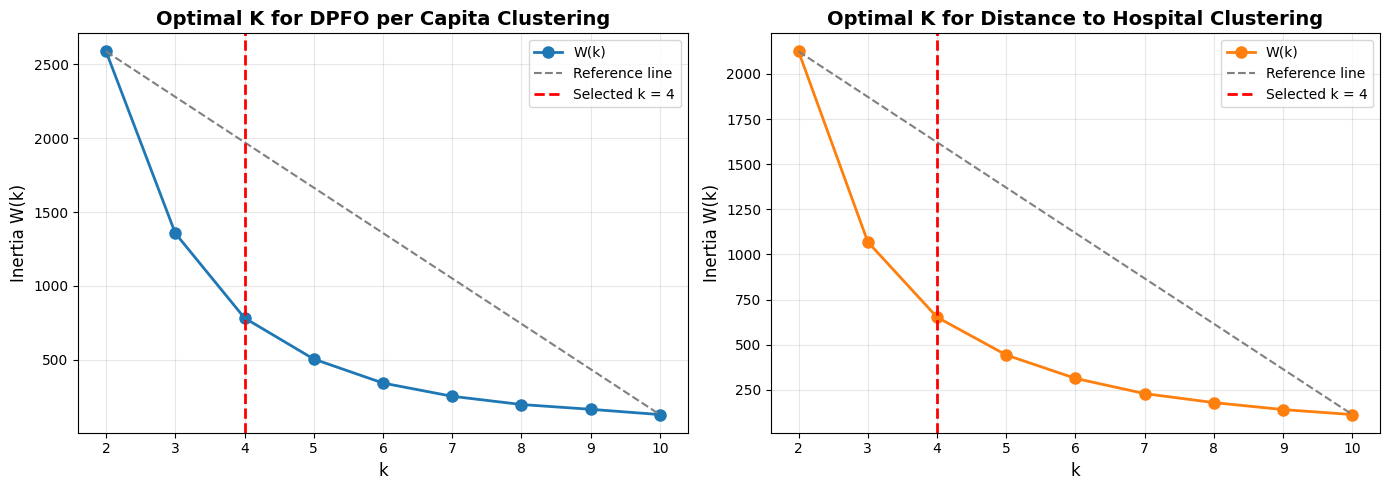

In [9]:
# Combined plot: Optimal K for both DPFO and Distance to Hospital
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Define K values to test
K_VALUES = [2, 3, 4, 5, 6, 7, 8, 9, 10]

# --- DPFO per capita clustering ---
scaler_dpfo = StandardScaler()
X_dpfo_scaled = scaler_dpfo.fit_transform(cities_df[['DPFO_per_capita']])
W_dpfo = compute_W_for_ks(X_dpfo_scaled, ks=K_VALUES)
k_star_dpfo = elbow_choose_k(ks=K_VALUES, W=W_dpfo)

# --- Distance to hospital clustering ---
scaler_dist = StandardScaler()
X_dist_scaled = scaler_dist.fit_transform(cities_df[['Vzdalenost_km']])
W_dist = compute_W_for_ks(X_dist_scaled, ks=K_VALUES)
k_star_dist = elbow_choose_k(ks=K_VALUES, W=W_dist)

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left subplot: DPFO per capita ---
ax1 = axes[0]
ks_arr = np.asarray(K_VALUES, dtype=float)
W_dpfo_arr = np.asarray(W_dpfo, dtype=float)

# Line endpoints for DPFO
x1, y1 = ks_arr[0], W_dpfo_arr[0]
x2, y2 = ks_arr[-1], W_dpfo_arr[-1]

# Plot inertia curve
ax1.plot(ks_arr, W_dpfo_arr, marker='o', label="W(k)", linewidth=2, markersize=8)

# Reference line
ax1.plot([x1, x2], [y1, y2], linestyle='--', color='gray', label="Reference line", linewidth=1.5)

# Highlight elbow
ax1.axvline(k_star_dpfo, linestyle='--', color='red', linewidth=2, label=f"Selected k = {k_star_dpfo}")

ax1.set_xlabel("k", fontsize=12)
ax1.set_ylabel("Inertia W(k)", fontsize=12)
ax1.set_title("Optimal K for DPFO per Capita Clustering", fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# --- Right subplot: Distance to Hospital ---
ax2 = axes[1]
W_dist_arr = np.asarray(W_dist, dtype=float)

# Line endpoints for Distance
x1_d, y1_d = ks_arr[0], W_dist_arr[0]
x2_d, y2_d = ks_arr[-1], W_dist_arr[-1]

# Plot inertia curve
ax2.plot(ks_arr, W_dist_arr, marker='o', label="W(k)", linewidth=2, markersize=8, color='tab:orange')

# Reference line
ax2.plot([x1_d, x2_d], [y1_d, y2_d], linestyle='--', color='gray', label="Reference line", linewidth=1.5)

# Highlight elbow
ax2.axvline(k_star_dist, linestyle='--', color='red', linewidth=2, label=f"Selected k = {k_star_dist}")

ax2.set_xlabel("k", fontsize=12)
ax2.set_ylabel("Inertia W(k)", fontsize=12)
ax2.set_title("Optimal K for Distance to Hospital Clustering", fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# Adjust layout
plt.tight_layout()

# Save as PDF
plt.savefig('../results/optimal_k_comparison.pdf', bbox_inches='tight', dpi=300)
print(f"Saved combined plot to ../results/optimal_k_comparison.pdf")
print(f"Optimal k for DPFO per capita: {k_star_dpfo}")
print(f"Optimal k for Distance to Hospital: {k_star_dist}")

plt.show()

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import numpy as np

# -----------------------------
# Params
# -----------------------------
K_VALUES = [2, 3, 4, 5, 6, 7]
ROWS, COLS = 2, 3

HSPACE = 0.06
VSPACE = 0.10

EXPORT_W = 2000
EXPORT_H = 1200
EXPORT_SCALE = 3

# -----------------------------
# Scale distance
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cities_df[['Vzdalenost_km']])

# -----------------------------
# Create subplot grid: 2 rows x 3 cols
# -----------------------------
fig = make_subplots(
    rows=ROWS,
    cols=COLS,
    specs=[[{'type': 'scene'}] * COLS for _ in range(ROWS)],
    subplot_titles=[f'k = {k}' for k in K_VALUES],
    horizontal_spacing=HSPACE,
    vertical_spacing=VSPACE
)

# -----------------------------
# Add traces
# -----------------------------
for idx, k in enumerate(K_VALUES):
    row = idx // COLS + 1
    col = idx % COLS + 1

    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    # Order clusters by distance (low -> high)
    centers = kmeans.cluster_centers_.flatten()
    order = np.argsort(centers)
    mapping = {old: new for new, old in enumerate(order)}
    ordered_labels = np.array([mapping[l] for l in labels])

    fig.add_trace(
        go.Scatter3d(
            x=cities_df['Lon_x'],
            y=cities_df['Lat_x'],
            z=cities_df['Vzdalenost_km'],
            mode='markers',
            marker=dict(
                size=2,
                color=ordered_labels,
                colorscale='Jet',
                opacity=0.8
            ),
            hovertext=cities_df['Nazev_obce_prijmy'],
            showlegend=False
        ),
        row=row,
        col=col
    )

    fig.update_scenes(
        dict(
            xaxis_title='Lon.',
            yaxis_title='Lat.',
            zaxis_title='Dist. (km)',
            xaxis=dict(autorange='reversed'),
            yaxis=dict(autorange='reversed'),
            camera=dict(eye=dict(x=1.5, y=1.5, z=0.1))
        ),
        row=row,
        col=col
    )
    
fig.update_annotations(font=dict(size=26))
# -----------------------------
# Layout + save
# -----------------------------
fig.update_layout(
    height=EXPORT_H,
    width=EXPORT_W,
    title=dict(
        text='Clustering by Distance to Nearest Hospital (k = 2–7)',
        font=dict(size=32),   # 👈 tady zvětšíš jen hlavní nadpis
        x=0.5,                # vycentrovat
        xanchor='center'
    ),
    margin=dict(l=10, r=10, b=10, t=60)
)

fig.show()

fig.write_image(
    "../results/3d_scatter_distance_clusters_k2_3_4_5_6_7.pdf",
    width=EXPORT_W,
    height=EXPORT_H,
    scale=EXPORT_SCALE
)

# Optional: often looks better than PDF for 3D
fig.write_image(
    "../results/3d_scatter_distance_clusters_k2_3_4_5_6_7.png",
    width=EXPORT_W,
    height=EXPORT_H,
    scale=EXPORT_SCALE
)

Perform clustering based on geographical location

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import plotly.graph_objects as go
import numpy as np

# --------------------------------
# Perform clustering based on Lon & Lat
# --------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cities_df[['Lon_x', 'Lat_x']])

number_of_clusters = 13
kmeans = KMeans(n_clusters=number_of_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

# Sort clusters west → east (by longitude)
cluster_centers_lon = kmeans.cluster_centers_[:, 0]
cluster_order = np.argsort(cluster_centers_lon)
cluster_mapping = {old: new for new, old in enumerate(cluster_order)}

cities_df['cluster_location'] = np.array(
    [cluster_mapping[l] for l in cluster_labels])

# reorder centroids accordingly
centroids_scaled = kmeans.cluster_centers_[cluster_order]
centroids = scaler.inverse_transform(centroids_scaled)

# --------------------------------
# Find closest municipality to each centroid
# --------------------------------
rep_lon, rep_lat, rep_name = [], [], []
for cx, cy in centroids:
    dists = (cities_df['Lon_x'] - cx)**2 + (cities_df['Lat_x'] - cy)**2
    idx = dists.idxmin()
    rep_lon.append(float(cities_df.loc[idx, 'Lon_x']))
    rep_lat.append(float(cities_df.loc[idx, 'Lat_x']))
    rep_name.append(str(cities_df.loc[idx, 'Nazev_obce_prijmy']))

# Labels: "Cluster i: NAME" (bold)
rep_labels = [f"<b>Cluster {i}: {name}</b>" for i, name in enumerate(rep_name)]

# --------------------------------
# 2D Scatter plot
# --------------------------------
fig = go.Figure()

# All municipalities
fig.add_trace(
    go.Scatter(
        x=cities_df['Lon_x'],
        y=cities_df['Lat_x'],
        mode='markers',
        marker=dict(
            size=4,
            color=cities_df['cluster_location'],
            colorscale='Jet',
            opacity=0.75
        ),
        hovertext=cities_df['Nazev_obce_prijmy'],
        showlegend=False
    )
)

# Centroids
fig.add_trace(
    go.Scatter(
        x=centroids[:, 0],
        y=centroids[:, 1],
        mode='markers',
        marker=dict(
            symbol='x',
            size=14,
            color='black',
            line=dict(width=3)
        ),
        showlegend=False
    )
)

# Representative municipalities + labels
fig.add_trace(
    go.Scatter(
        x=rep_lon,
        y=rep_lat,
        mode='markers+text',
        marker=dict(
            size=10,
            color='black',
            symbol='circle-open',
            line=dict(width=3, color='white')  # "halo" around marker
        ),
        text=rep_labels,
        textposition='top center',
        textfont=dict(size=16, color='black', family='Arial'),
        showlegend=False,
        hoverinfo='skip'
    )
)

fig.update_layout(
    showlegend=False,  # <-- remove legend globally
    xaxis_title='Longitude',
    yaxis_title='Latitude',
    title=dict(
        text='Clustering by Location (Lon & Lat)',
        font=dict(size=32),
        x=0.5,
        xanchor='center'
    ),
    height=800,
    width=900,
    margin=dict(l=40, r=20, b=40, t=80)
)

fig.show()

# Save
fig.write_image(
    "../results/2d_scatter_location_clusters.pdf",
    width=900,
    height=800,
    scale=3
)

Lets see the resulting clusters and their representatives

In [12]:
import numpy as np
import pandas as pd


def print_closest_cities(df, cluster_col, feature_cols, name_col='Nazev_obce_prijmy', title=""):
    print(f"\n--- {title} ---")

    # 1. Spočítáme střed (průměr) pro každý cluster
    centroids = df.groupby(cluster_col)[feature_cols].mean()

    results = []

    # 2. Projdeme každý cluster
    for cluster_label in sorted(df[cluster_col].unique()):
        # Vyfiltrujeme města v daném clusteru
        cluster_data = df[df[cluster_col] == cluster_label].copy()

        # Získáme souřadnice středu pro tento cluster
        center = centroids.loc[cluster_label]

        # 3. Vypočítáme vzdálenost každého města od středu
        # (Funguje pro 1D i 2D díky mocnině a odmocnině)
        distances = np.sqrt(
            ((cluster_data[feature_cols] - center) ** 2).sum(axis=1))

        # 4. Najdeme index města s minimální vzdáleností
        closest_idx = distances.idxmin()
        closest_city = cluster_data.loc[closest_idx, name_col]
        closest_val = cluster_data.loc[closest_idx, feature_cols].values

        # Uložíme formátovaný výstup
        if len(feature_cols) == 1:
            val_str = f"{feature_cols[0]}: {closest_val[0]:.2f}"
        else:
            val_str = f"Coords: {closest_val}"

        print(
            f"Cluster {cluster_label}: Nejbližší město k centru -> {closest_city} ({val_str})")


# 1. Pro DPFO (1D)
print_closest_cities(
    cities_df,
    cluster_col='cluster',
    feature_cols=['DPFO_per_capita'],
    title="Centrální města pro DPFO Clustery"
)

# 2. Pro Vzdálenost k nemocnici (1D)
print_closest_cities(
    cities_df,
    cluster_col='cluster_distance',
    feature_cols=['Vzdalenost_km'],
    title="Centrální města pro Clustery Vzdálenosti"
)

# 3. Pro Lokaci (2D - Lat, Lon)
print_closest_cities(
    cities_df,
    cluster_col='cluster_location',
    feature_cols=['Lon_x', 'Lat_x'],
    title="Geografická centra clusterů (Nejbližší obec ke středu)"
)


--- Centrální města pro DPFO Clustery ---
Cluster 0: Nejbližší město k centru -> NADRYBY (DPFO_per_capita: 11.54)
Cluster 1: Nejbližší město k centru -> MOCHOV (DPFO_per_capita: 13.65)
Cluster 2: Nejbližší město k centru -> LIPTÁL (DPFO_per_capita: 15.36)
Cluster 3: Nejbližší město k centru -> ŠÍPY (DPFO_per_capita: 18.04)

--- Centrální města pro Clustery Vzdálenosti ---
Cluster 0: Nejbližší město k centru -> STUDNICE (Vzdalenost_km: 5.62)
Cluster 1: Nejbližší město k centru -> SKOTNICE (Vzdalenost_km: 11.30)
Cluster 2: Nejbližší město k centru -> VITICE (Vzdalenost_km: 17.56)
Cluster 3: Nejbližší město k centru -> KRÁSNÉ (Vzdalenost_km: 26.30)

--- Geografická centra clusterů (Nejbližší obec ke středu) ---
Cluster 0: Nejbližší město k centru -> KRÁSNÝ DVŮR (Coords: [np.float64(13.3677654) np.float64(50.2541629)])
Cluster 1: Nejbližší město k centru -> VŠENICE (Coords: [np.float64(13.5603631) np.float64(49.8181481)])
Cluster 2: Nejbližší město k centru -> KRAMOLÍN (Coords: [np.float6

In [13]:
print(cities_df[cities_df["Cislo_obce"]==554782])

Empty DataFrame
Columns: [Nazev_obce_prijmy, Nejblizsi_nemocnice, Vzdalenost_km, Lat_x, Lon_x, DPFO, Total, Cislo_obce, Index_stari, DPFO_per_capita, cluster, cluster_distance, cluster_location]
Index: []


Lets analyze results

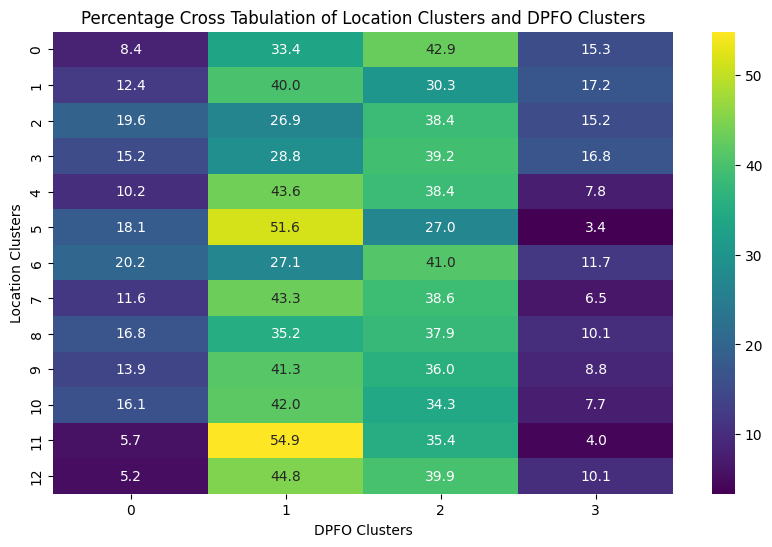

In [14]:
# How do the location clusters overlap with DPFO clusters?
cross_tab_loc = pd.crosstab(cities_df['cluster_location'], cities_df['cluster'])
# How do the location clusters overlap with DPFO clusters?
cross_tab_loc = pd.crosstab(cities_df['cluster_location'], cities_df['cluster'],
                            normalize='index') * 100
plt.figure(figsize=(10, 6))
sns.heatmap(cross_tab_loc, annot=True, fmt='.1f', cmap='viridis')
plt.title('Percentage Cross Tabulation of Location Clusters and DPFO Clusters')
plt.xlabel('DPFO Clusters')
plt.ylabel('Location Clusters')
plt.show()


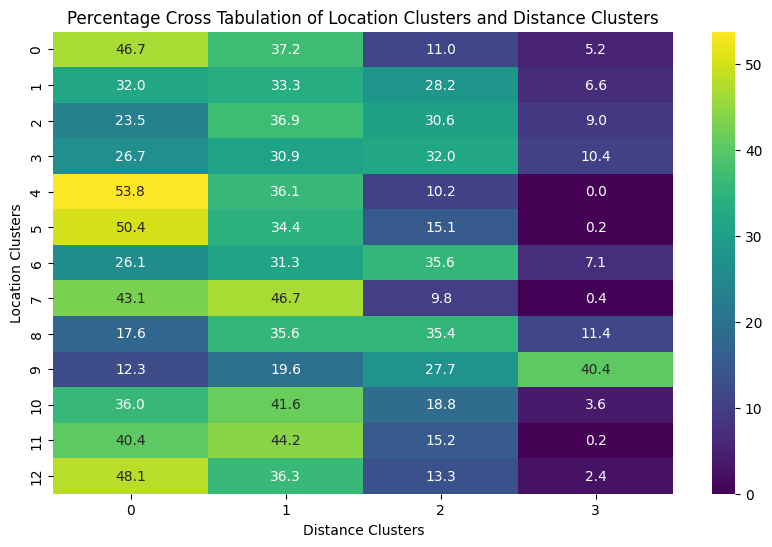

In [15]:
# How do the location clusters overlap with Distance clusters?
cross_tab_loc_dist = pd.crosstab(cities_df['cluster_location'], cities_df['cluster_distance'])
# How do the location clusters overlap with Distance clusters?
cross_tab_loc_dist = pd.crosstab(cities_df['cluster_location'], cities_df['cluster_distance'],
                            normalize='index') * 100
plt.figure(figsize=(10, 6))
sns.heatmap(cross_tab_loc_dist, annot=True, fmt='.1f', cmap='viridis')
plt.title('Percentage Cross Tabulation of Location Clusters and Distance Clusters')
plt.xlabel('Distance Clusters')
plt.ylabel('Location Clusters')
plt.show()

Saved combined cross tabulations to ../results/combined_cross_tabulations.pdf


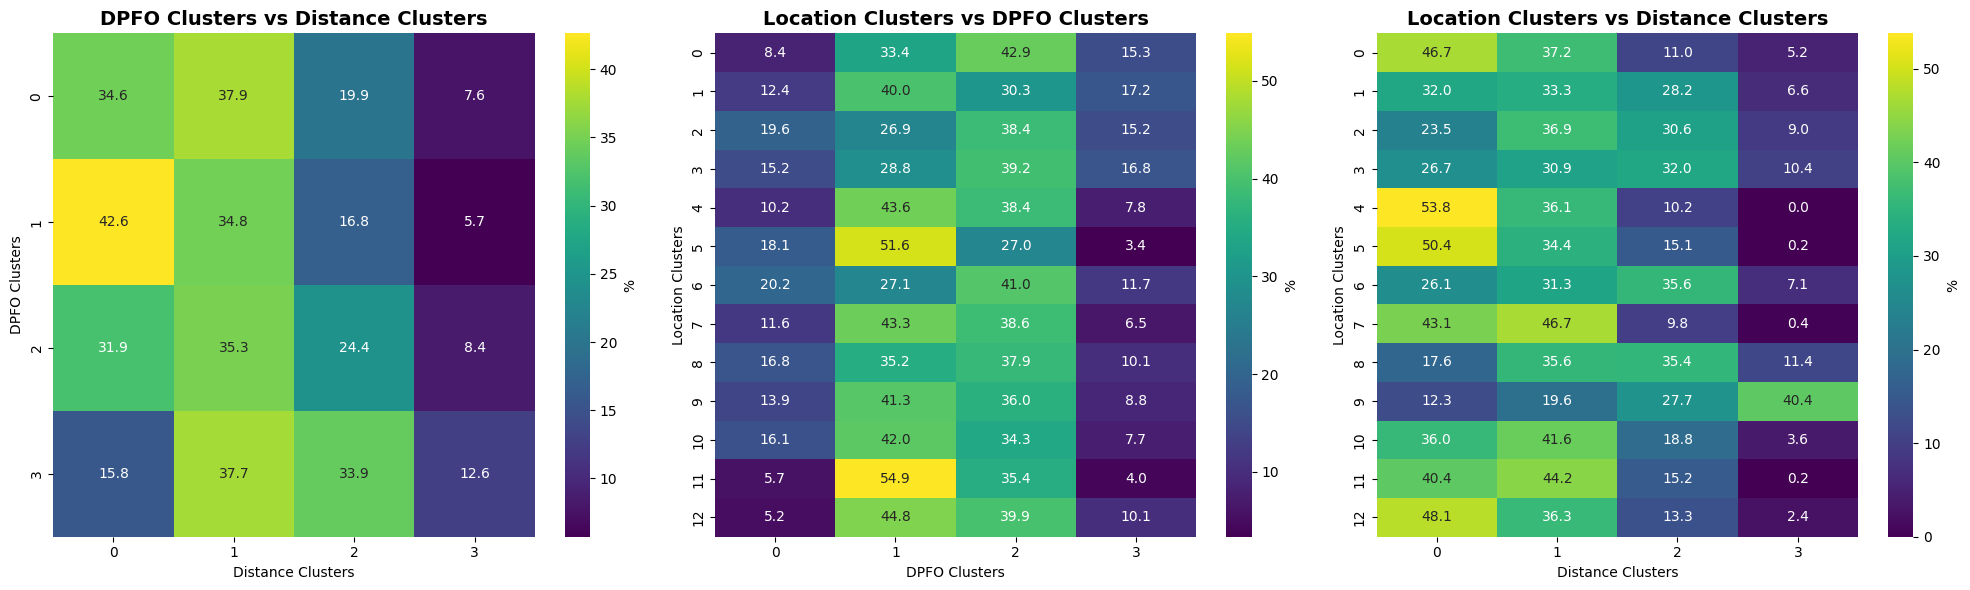

In [16]:
# Combined Cross Tabulations - 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. DPFO Clusters vs Distance Clusters
cross_tab1 = pd.crosstab(cities_df['cluster'], cities_df['cluster_distance'], normalize='index') * 100
sns.heatmap(cross_tab1, annot=True, fmt='.1f', cmap='viridis', ax=axes[0], cbar_kws={'label': '%'})
axes[0].set_title('DPFO Clusters vs Distance Clusters', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Distance Clusters')
axes[0].set_ylabel('DPFO Clusters')

# 2. Location Clusters vs DPFO Clusters
cross_tab2 = pd.crosstab(cities_df['cluster_location'], cities_df['cluster'], normalize='index') * 100
sns.heatmap(cross_tab2, annot=True, fmt='.1f', cmap='viridis', ax=axes[1], cbar_kws={'label': '%'})
axes[1].set_title('Location Clusters vs DPFO Clusters', fontsize=14, fontweight='bold')
axes[1].set_xlabel('DPFO Clusters')
axes[1].set_ylabel('Location Clusters')

# 3. Location Clusters vs Distance Clusters
cross_tab3 = pd.crosstab(cities_df['cluster_location'], cities_df['cluster_distance'], normalize='index') * 100
sns.heatmap(cross_tab3, annot=True, fmt='.1f', cmap='viridis', ax=axes[2], cbar_kws={'label': '%'})
axes[2].set_title('Location Clusters vs Distance Clusters', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Distance Clusters')
axes[2].set_ylabel('Location Clusters')

plt.tight_layout()
plt.savefig('../results/combined_cross_tabulations.pdf', bbox_inches='tight', dpi=300)
print("Saved combined cross tabulations to ../results/combined_cross_tabulations.pdf")
plt.show()

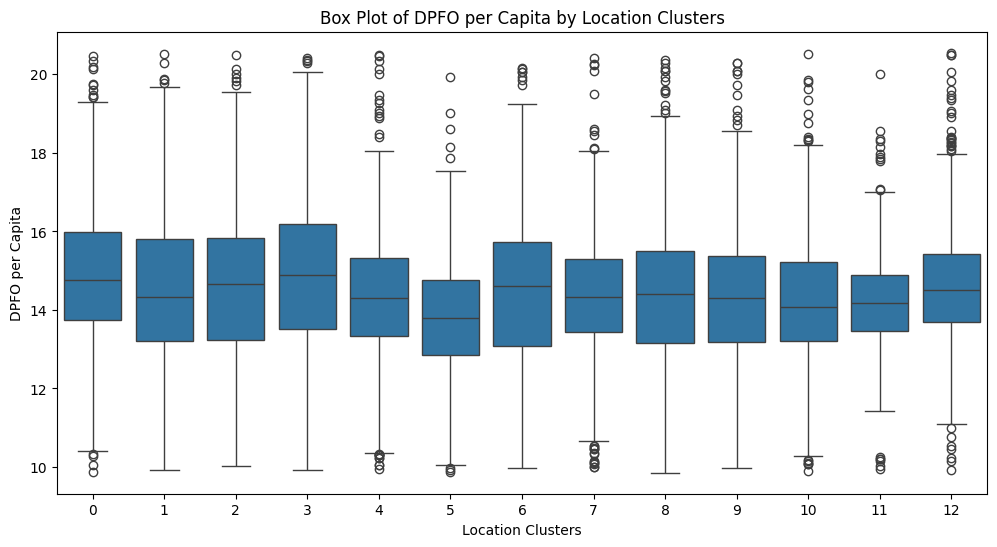

In [17]:
#box plots for DPFO per capita by location clusters
plt.figure(figsize=(12, 6))
sns.boxplot(x='cluster_location', y='DPFO_per_capita', data=cities_df)
plt.title('Box Plot of DPFO per Capita by Location Clusters')
plt.xlabel('Location Clusters')
plt.ylabel('DPFO per Capita')
plt.show()

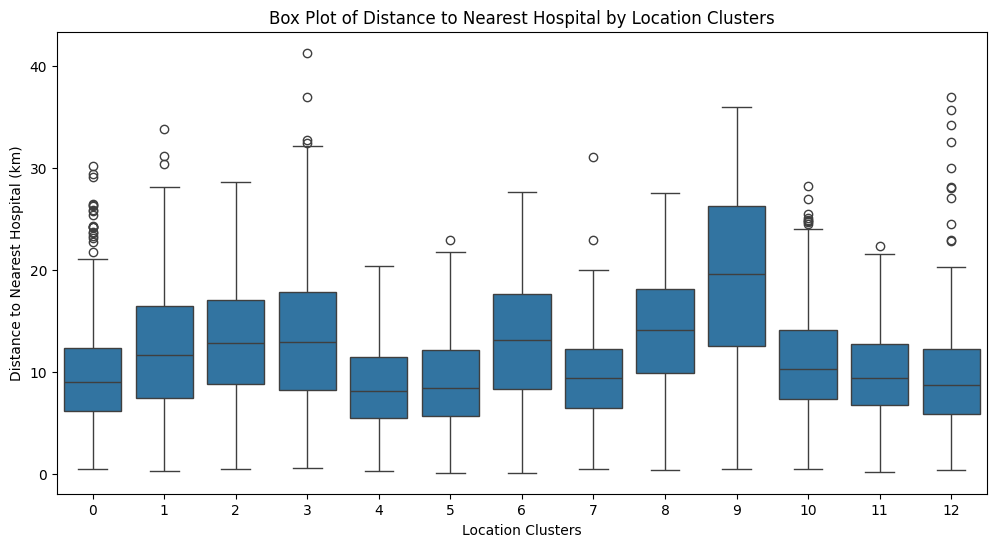

In [18]:
#box plots for Distance to nearest hospital by location clusters
plt.figure(figsize=(12, 6))
sns.boxplot(x='cluster_location', y='Vzdalenost_km', data=cities_df)
plt.title('Box Plot of Distance to Nearest Hospital by Location Clusters')
plt.xlabel('Location Clusters')
plt.ylabel('Distance to Nearest Hospital (km)')
plt.show()

Saved combined boxplots to ../results/combined_boxplots.pdf


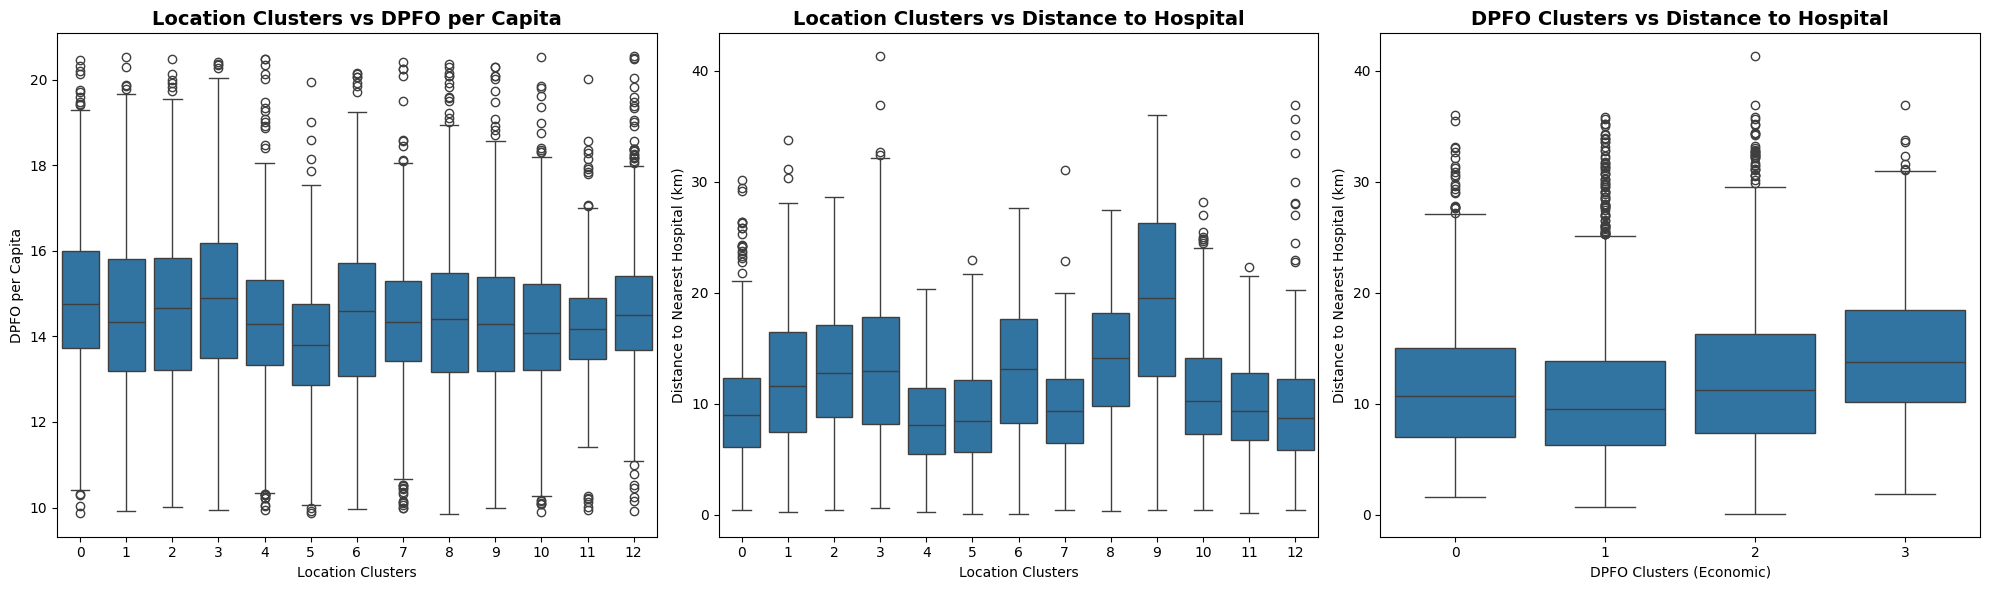

In [ ]:
# Combined Box Plots - 3 subplots (matching stacked bar plots)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
F
# 1. Location Clusters vs DPFO per capita
sns.boxplot(x='cluster_location', y='DPFO_per_capita', data=cities_df, ax=axes[0])
axes[0].set_title('Location Clusters vs DPFO per Capita', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Location Clusters')
axes[0].set_ylabel('DPFO per Capita')

# 2. Location Clusters vs Distance to Hospital
sns.boxplot(x='cluster_location', y='Vzdalenost_km', data=cities_df, ax=axes[1])
axes[1].set_title('Location Clusters vs Distance to Hospital', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Location Clusters')
axes[1].set_ylabel('Distance to Nearest Hospital (km)')

# 3. DPFO Clusters vs Distance to Hospital
sns.boxplot(x='cluster', y='Vzdalenost_km', data=cities_df, ax=axes[2])
axes[2].set_title('DPFO Clusters vs Distance to Hospital', fontsize=14, fontweight='bold')
axes[2].set_xlabel('DPFO Clusters (Economic)')
axes[2].set_ylabel('Distance to Nearest Hospital (km)')

plt.tight_layout()
plt.savefig('../results/combined_boxplots.pdf', bbox_inches='tight', dpi=300)
print("Saved combined boxplots to ../results/combined_boxplots.pdf")
plt.show()

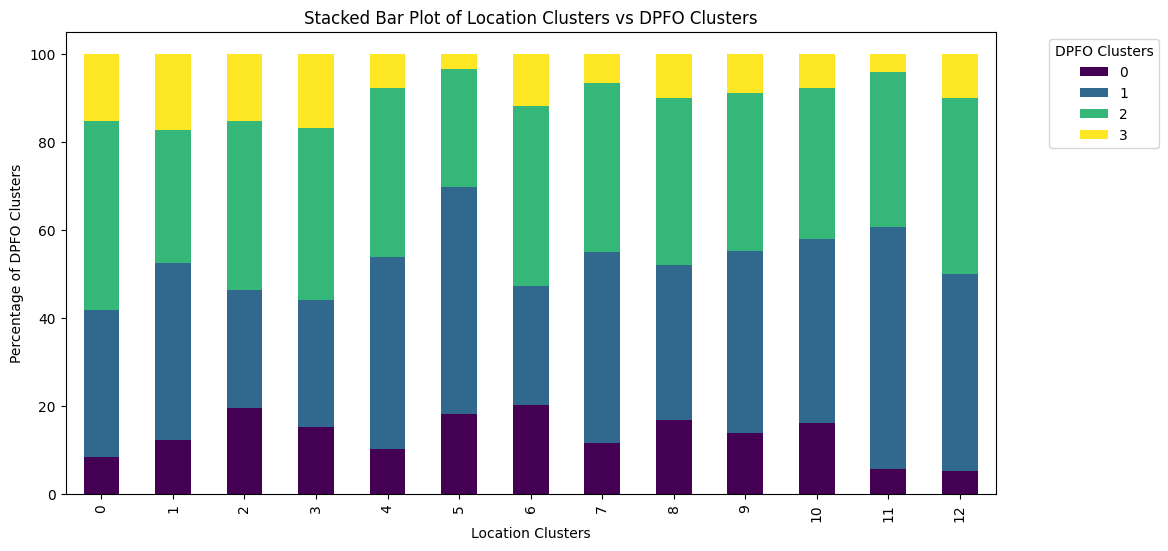

In [ ]:
   .      #stacked bar plot for location clusters vs DPFO clusters
cross_tab_loc = pd.crosstab(cities_df['cluster_location'], cities_df['cluster'],
                            normalize='index') * 100
cross_tab_loc.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
plt.title('Stacked Bar Plot of Location Clusters vs DPFO Clusters')
plt.xlabel('Location Clusters')
plt.ylabel('Percentage of DPFO Clusters')
plt.legend(title='DPFO Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

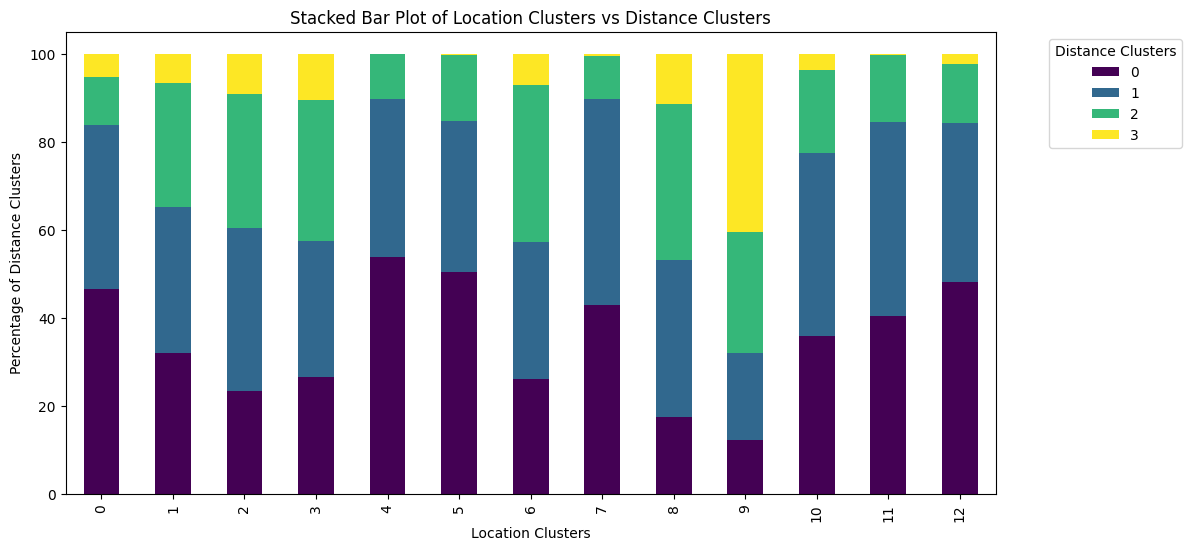

In [21]:
#stacked bar plot for location clusters vs Distance clusters
cross_tab_loc_dist = pd.crosstab(cities_df['cluster_location'], cities_df['cluster_distance'],
                            normalize='index') * 100
cross_tab_loc_dist.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
plt.title('Stacked Bar Plot of Location Clusters vs Distance Clusters')
plt.xlabel('Location Clusters')
plt.ylabel('Percentage of Distance Clusters')
plt.legend(title='Distance Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
#save plot to file - MUST be before plt.show()
plt.savefig('location_vs_distance_clusters_stacked_bar.pdf', bbox_inches='tight')
plt.show()

Saved combined stacked bar plots to ../results/combined_stacked_barplots.pdf


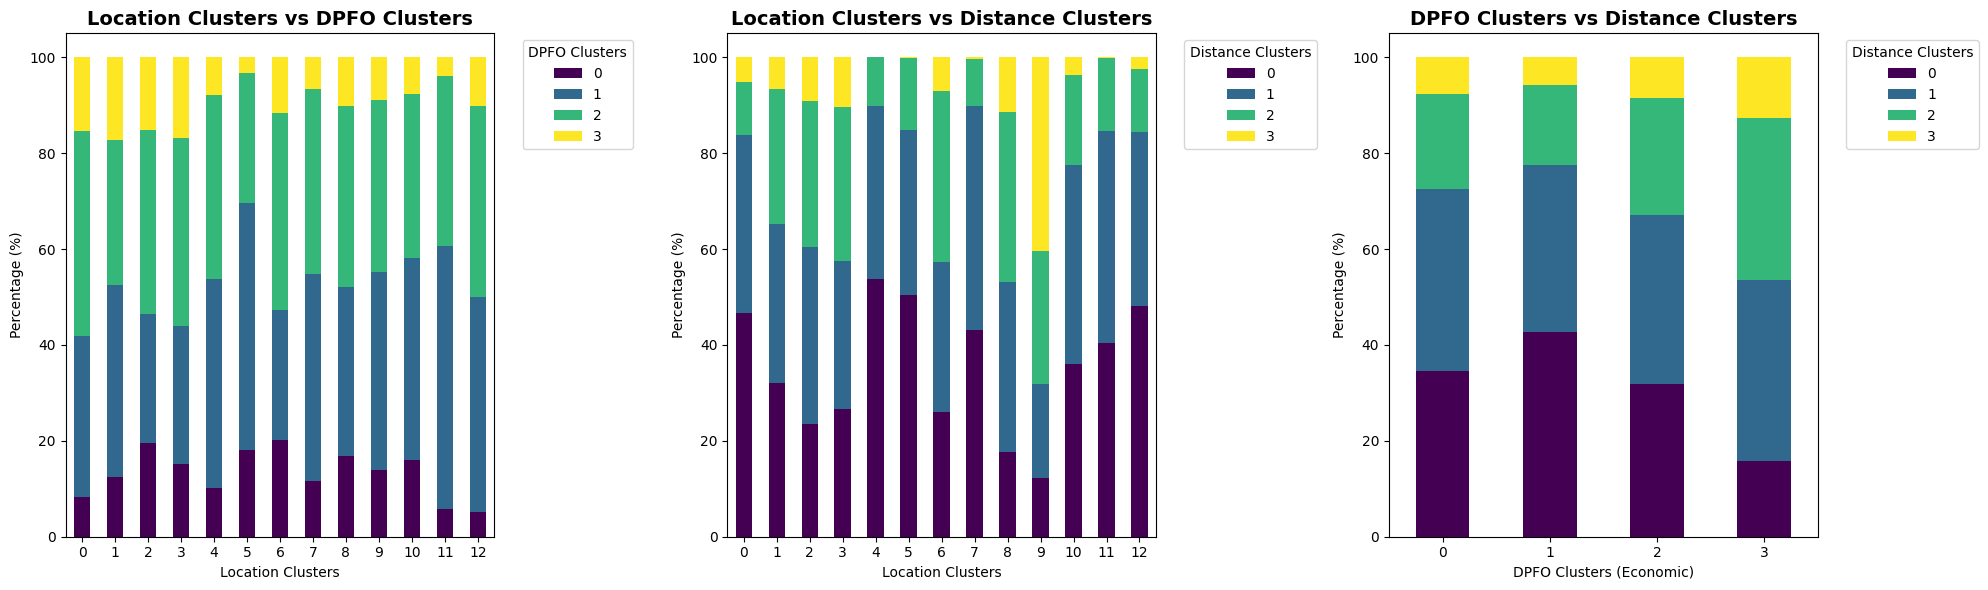

In [22]:
# Combined Stacked Bar Plots - 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Location Clusters vs DPFO Clusters
cross_tab_loc_dpfo = pd.crosstab(cities_df['cluster_location'], cities_df['cluster'], normalize='index') * 100
cross_tab_loc_dpfo.plot(kind='bar', stacked=True, ax=axes[0], colormap='viridis')
axes[0].set_title('Location Clusters vs DPFO Clusters', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Location Clusters')
axes[0].set_ylabel('Percentage (%)')
axes[0].legend(title='DPFO Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# 2. Location Clusters vs Distance Clusters
cross_tab_loc_dist = pd.crosstab(cities_df['cluster_location'], cities_df['cluster_distance'], normalize='index') * 100
cross_tab_loc_dist.plot(kind='bar', stacked=True, ax=axes[1], colormap='viridis')
axes[1].set_title('Location Clusters vs Distance Clusters', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Location Clusters')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(title='Distance Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

# 3. DPFO Clusters vs Distance Clusters (NEW!)
cross_tab_dpfo_dist = pd.crosstab(cities_df['cluster'], cities_df['cluster_distance'], normalize='index') * 100
cross_tab_dpfo_dist.plot(kind='bar', stacked=True, ax=axes[2], colormap='viridis')
axes[2].set_title('DPFO Clusters vs Distance Clusters', fontsize=14, fontweight='bold')
axes[2].set_xlabel('DPFO Clusters (Economic)')
axes[2].set_ylabel('Percentage (%)')
axes[2].legend(title='Distance Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('../results/combined_stacked_barplots.pdf', bbox_inches='tight', dpi=300)
print("Saved combined stacked bar plots to ../results/combined_stacked_barplots.pdf")
plt.show()

By examining the results, we observe no strong relationship between clusters based on
\textit{distance to the nearest hospital} and \textit{DPFO} across the Czech Republic.
In contrast, a relatively strong relationship is evident between geographic location
clusters and both economic regions and hospital accessibility, reflecting differences
in healthcare accessibility.

For geographic cluster No.~11 (corresponding approximately to the Zlín Region),
more than half of the municipalities belong to the second lowest \textit{DPFO} cluster
($54.9\%$), and when combined with the lowest \textit{DPFO} cluster, this proportion
exceeds $60\%$.

An even more pronounced pattern is observed for geographic cluster No.~4
(approximately corresponding to the Liberec Region). In this cluster, more than half
of the municipalities fall into the best cluster according to
\textit{distance to the nearest hospital}, while none belong to the worst cluster.
This indicates that this region likely exhibits the best healthcare accessibility.
A similar trend is observed for geographic cluster No.~5 (approximately corresponding
to the Central Bohemian Region), which also demonstrates very good access to hospital
facilities.

As shown in Figs.~\ref{fig:box_plots} and \ref{fig:bar_plots}, geographic clusters differ
only moderately in terms of \textit{DPFO}, but exhibit more pronounced differences in
\textit{distance to the nearest hospital}. In particular, the box plots reveal that
geographic cluster No.~9 (roughly corresponding to parts of the Pardubice and Olomouc
Regions) stands out with the highest distances to the nearest hospital, suggesting that
this region has the poorest access to healthcare facilities.